In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Introduction**

This project aims to predict whether a loan application will be approved based on applicant information such as income, education, employment, credit history, and property area. Using machine learning, we preprocess the data, analyze patterns, select important features, and train classifiers to assist banks in making faster and more accurate loan decisions.

# **Problem Statement**

Banks and financial institutions need to decide quickly and accurately whether to approve loan applications. Manual assessment can be slow and error-prone. The goal of this project is to build a machine learning model that predicts loan approval based on applicant features, helping automate and improve the decision-making process.


# **Dataset**

The dataset used for this project is the Loan Prediction Problem Dataset. Each applicant is described by the following features:

| Column            | Description                        |
| ----------------- | ---------------------------------- |
| Loan_ID           | Unique loan identifier             |
| Gender            | Male/Female                        |
| Married           | Whether married (Yes/No)           |
| Dependents        | Number of dependents               |
| Education         | Graduate/Undergraduate             |
| Self_Employment   | Self-employed status (Yes/No)      |
| ApplicantIncome   | Applicant’s income                 |
| CoapplicantIncome | Co-applicant’s income              |
| LoanAmount        | Loan amount (in thousands)         |
| Loan_Amount_Term  | Loan duration (in months)          |
| Credit_History    | Credit history (1 = good, 0 = bad) |
| Property_Area     | Urban/Semiurban/Rural              |
| Loan_Status       | Loan approved (Yes/No)             |

The dataset contains 614 rows and 13 columns.



---



In [2]:
#Data Analysis Libraries
import numpy as np
import pandas as pd

#Data Viz Libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Data Processing
from sklearn import preprocessing

#Data Splitting
from sklearn.model_selection import train_test_split

#ML Libraries
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.metrics import (confusion_matrix,accuracy_score,precision_score,recall_score,f1_score)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

In [3]:
test_data = pd.read_csv('/content/test_Y3wMUE5_7gLdaTN.csv')
train_data = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

In [4]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
train_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# Data Pre-Processing & Data Analysis

**Missing Values**

Identifying and handling missing values

We can use a heatmap to visualize the dataset and identify missing values, then proceed to fill or remove them as appropriate.

In [7]:
train_data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


A better way to understand this more clealry is by visualizing it, we will visualize it through heatmap

<Axes: >

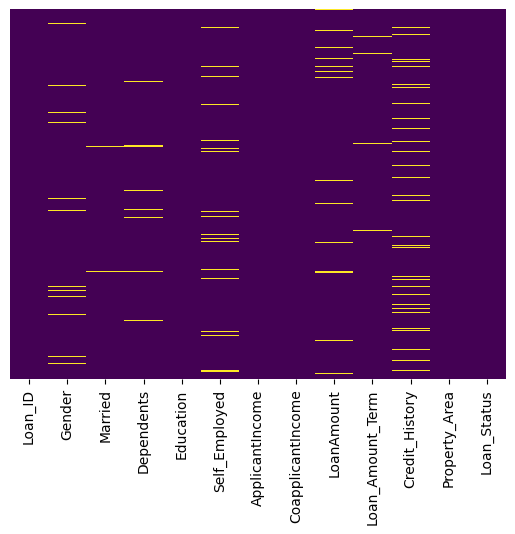

In [8]:
sns.heatmap(train_data.isnull(), yticklabels=False, cbar=False, cmap= 'viridis')

We will drop the Loan_ID column since it’s just an identifier for each applicant and doesn’t help with analysis or predicting loan approval.

In [ ]:
train_data.drop([('Loan_ID')], axis = 1, inplace=True)

Removing Missing Values for categorical terms with the help of mode

In [9]:
train_data['Gender'] = train_data['Gender'].fillna(train_data['Gender'].mode()[0])
train_data['Married'] = train_data['Married'].fillna(train_data['Married'].mode()[0])
train_data['Dependents'] = train_data['Dependents'].fillna(train_data['Dependents'].mode()[0])
train_data['Self_Employed'] = train_data['Self_Employed'].fillna(train_data['Self_Employed'].mode()[0])
train_data['Credit_History'] = train_data['Credit_History'].fillna(train_data['Credit_History'].mode()[0])
train_data['Loan_Amount_Term'] = train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mode()[0])

Removing Missing Values for numerical terms with the help of mean

In [10]:
train_data ['LoanAmount'] = train_data ['LoanAmount'].fillna(train_data['LoanAmount'].mean())
train_data ['Loan_Amount_Term'] = train_data ['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].mean())
train_data ['Credit_History'] = train_data ['Credit_History'].fillna(train_data['Credit_History'].mean())

In [11]:
train_data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


<Axes: >

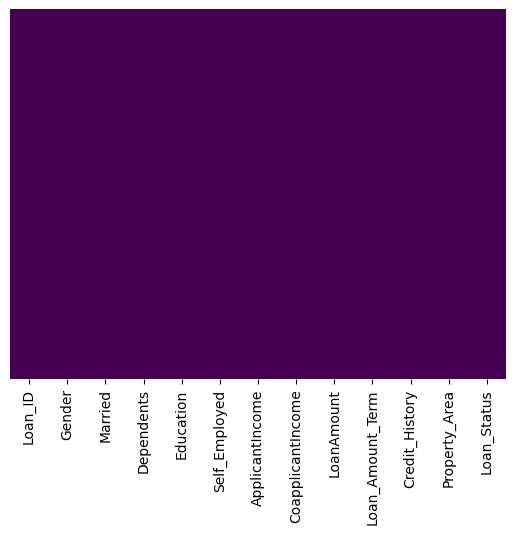

In [12]:
sns.heatmap(train_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [13]:
train_data.shape

(614, 13)

# Expolatory Data Analysis

We plot the counts of all categorical features to see the distribution of their values more clearly, for example: Gender (Male/Female), Married (Yes/No), and so on.

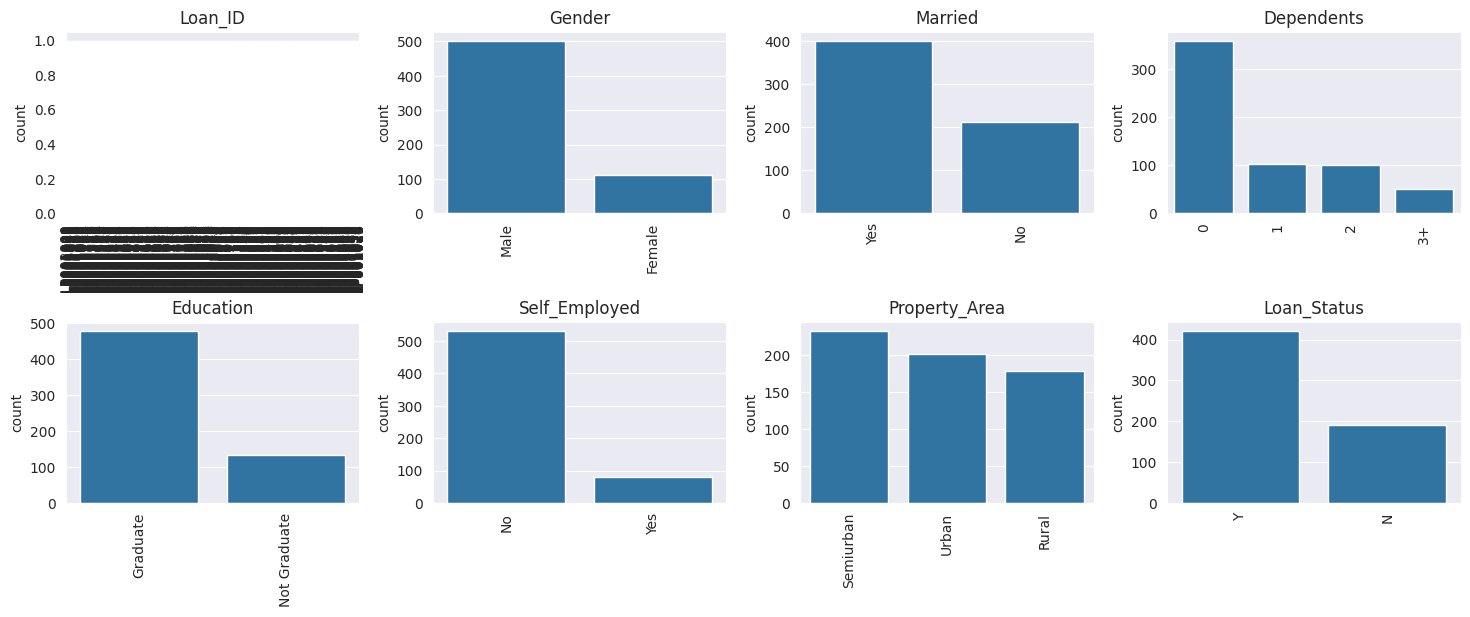

In [14]:
sns.set_style('darkgrid')
sns.set_palette('tab10')

obj = (train_data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.figure(figsize=(18,40))
index = 1

for col in object_cols:
    y = train_data[col].value_counts()
    plt.subplot(11,4,index)
    plt.xticks(rotation=90)
    plt.subplots_adjust(hspace = 0.6,wspace=0.25)
    sns.barplot(x=list(y.index), y=y).set_title(col)
    index +=1

From the above the plots we can see that most of the people applying for loans are: Male, Married, Graduates and not Self_Employed

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

<Figure size 600x2000 with 0 Axes>

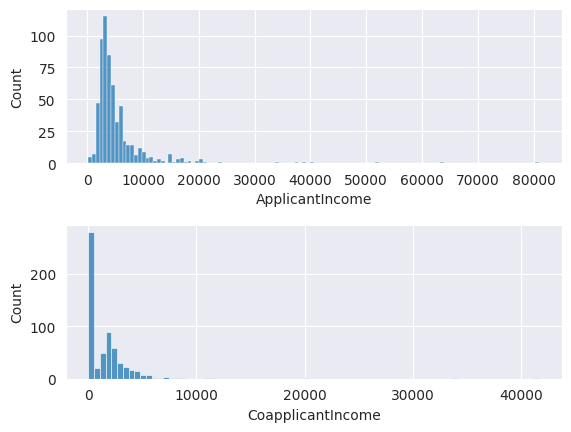

In [15]:
plt.figure(figsize=(6,20))

fig,axes = plt.subplots(2, 1, squeeze=False)

sns.histplot(train_data['ApplicantIncome'],ax=axes[0,0])
plt.subplots_adjust(hspace=0.4)
sns.histplot(train_data['CoapplicantIncome'],ax=axes[1,0])

One thing to note is that the Coapplicant Income is generally lower than the Applicant Income. This makes sense because, as seen in Plot 1, most applicants have 0 dependents, so the coapplicant contributes less income overall.

<Axes: xlabel='Loan_Amount_Term', ylabel='Count'>

<Figure size 600x2000 with 0 Axes>

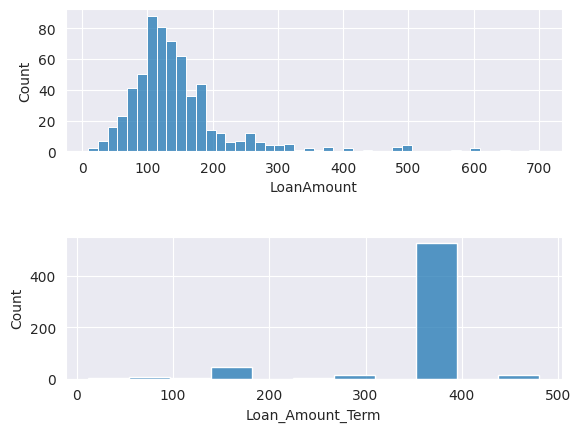

In [16]:
plt.figure(figsize=(6,20))

fig,axes = plt.subplots(2, 1, squeeze=False)

sns.histplot(train_data['LoanAmount'], ax=axes[0,0])
plt.subplots_adjust(hspace=0.6)
sns.histplot(train_data['Loan_Amount_Term'], ax=axes[1,0])

[Text(0.5, 1.0, 'Loan_Status based on Married')]

<Figure size 1000x400 with 0 Axes>

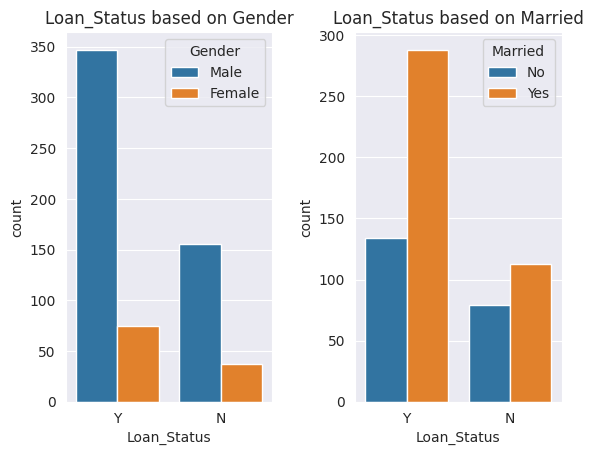

In [17]:
plt.figure(figsize=(10,4))

fig,axes = plt.subplots(1, 2, squeeze=False)

sns.countplot(ax=axes[0,0],x='Loan_Status',hue='Gender',data=train_data).set(title="Loan_Status based on Gender")
plt.subplots_adjust(wspace=0.4)
sns.countplot(ax=axes[0,1],x='Loan_Status',hue='Married',data=train_data).set(title="Loan_Status based on Married")

[Text(0.5, 1.0, 'Loan_Status based on Self_Employed')]

<Figure size 1000x400 with 0 Axes>

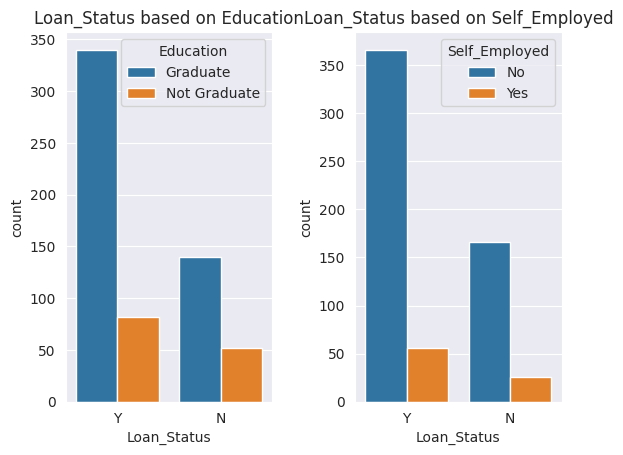

In [18]:
plt.figure(figsize=(10,4))

fig,axes = plt.subplots(1, 2, squeeze=False)

sns.countplot(ax=axes[0,0],x='Loan_Status',hue='Education',data=train_data).set(title="Loan_Status based on Education")
plt.subplots_adjust(wspace=0.4)
sns.countplot(ax=axes[0,1],x='Loan_Status',hue='Self_Employed',data=train_data).set(title="Loan_Status based on Self_Employed")

[Text(0.5, 1.0, 'Loan_Status based on Property_Area')]

<Figure size 1000x400 with 0 Axes>

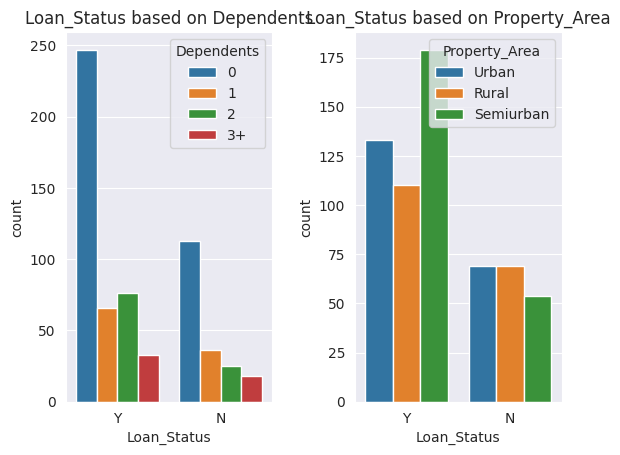

In [19]:
plt.figure(figsize=(10,4))

fig,axes = plt.subplots(1, 2, squeeze=False)

sns.countplot(ax=axes[0,0],x='Loan_Status',hue='Dependents',data=train_data).set(title="Loan_Status based on Dependents")
plt.subplots_adjust(wspace=0.4)
sns.countplot(ax=axes[0,1],x='Loan_Status',hue='Property_Area',data=train_data).set(title="Loan_Status based on Property_Area")

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

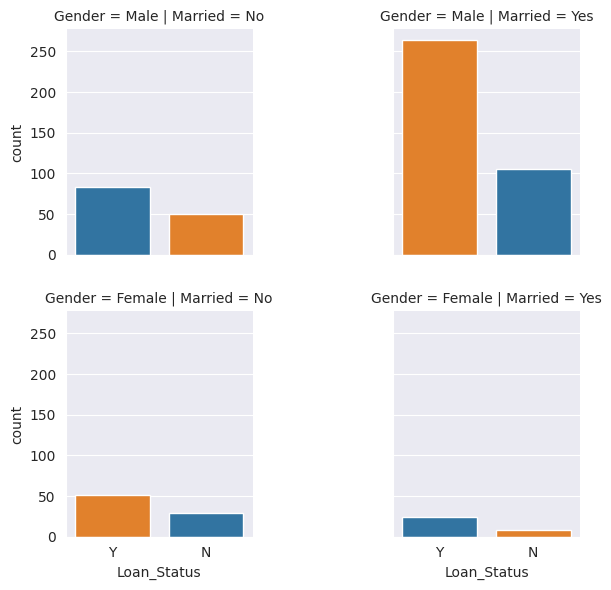

In [20]:
g = sns.FacetGrid(data=train_data,col='Married',row='Gender')

g.map(sns.countplot,'Loan_Status',palette="tab10")
plt.subplots_adjust(wspace = 0.75,hspace=0.25)

<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

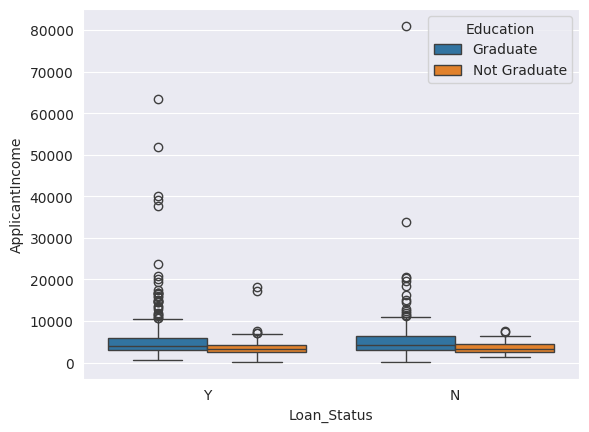

In [21]:
sns.boxplot(x='Loan_Status',y='ApplicantIncome',data=train_data,hue='Education')

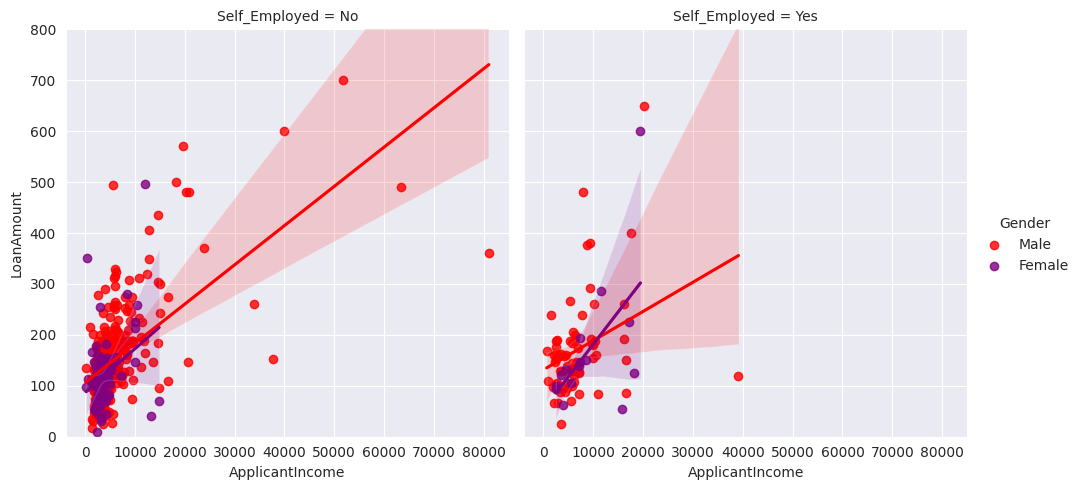

In [22]:
g = sns.lmplot(x='ApplicantIncome',y='LoanAmount',data= train_data , col='Self_Employed', hue='Gender',palette= ["Red" , "Purple","Yellow"])
g.set(ylim=(0, 800))

# Encoding

We convert the categorical variables (i.e., columns with object types) into numeric values using Label Encoding, so they can be used by machine learning models.

In [23]:
obj = (train_data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 8


In [24]:
label_encoder = preprocessing.LabelEncoder()
cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status','Dependents']
for col in cols:
  train_data[col] = label_encoder.fit_transform(train_data[col])

In [25]:
obj = (train_data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 1


# Correlation

<Axes: >

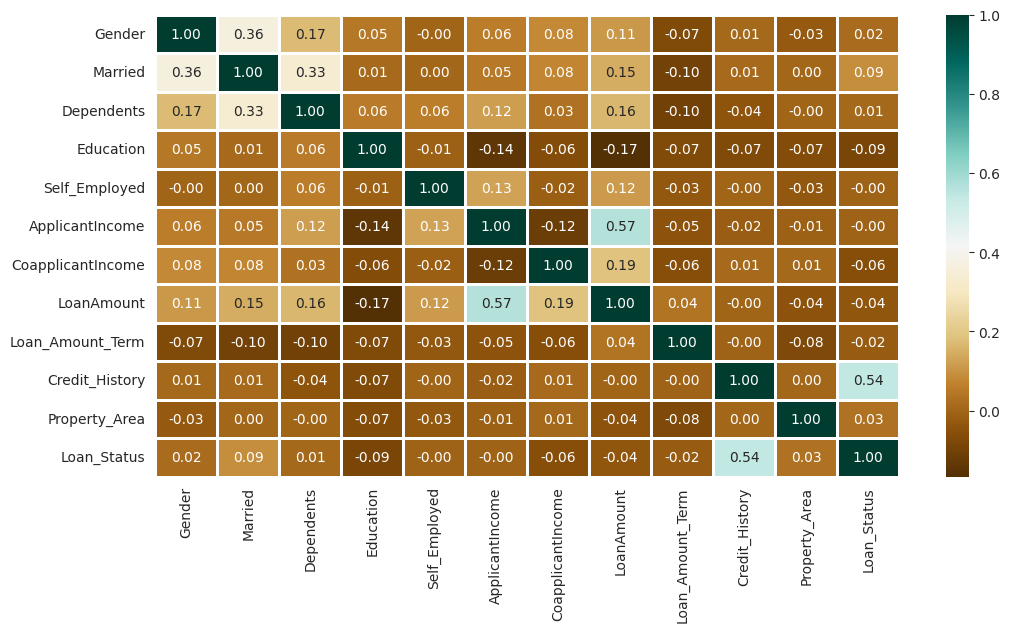

In [28]:
plt.figure(figsize=(12,6))

sns.heatmap(train_data.drop('Loan_ID', axis=1).corr(),cmap='BrBG',fmt='.2f',linewidths=2,annot=True)

We can see that the 'Loan_Status' of a person can be heavly affected by their 'Credit_History'

# Model Training

Now we train our models to predict whether a loan will be approved. We’ll start with Random Forest and Logistic Regression as our baseline to see how well simple models perform.

After that, we’ll try more advanced models like Gradient Boosting (XGBoost or LightGBM) to see if we can get better accuracy. For each model, we’ll check how well it performs using metrics like accuracy, precision, recall, and the confusion matrix.

In [33]:
from sklearn.model_selection import train_test_split

x_status = train_data.drop(['Loan_Status', 'Loan_ID'],axis=1)
y_status = train_data['Loan_Status']
x_status.shape,y_status.shape

x_train, x_test, y_train, y_test = train_test_split(x_status, y_status, test_size=0.3,random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((429, 11), (185, 11), (429,), (185,))

In [30]:
def clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test):
        model_clf.fit(x_train, y_train)
        y_train_pred = model_clf.predict(x_test)
        #y_test_pred= model_clf.predict(x_train)
        train_accuracy = model_clf.score(x_test,y_test)

        class_train_rep = classification_report(y_test,y_train_pred)

        print(model_clf.__class__.__name__, "Train :","\n",class_train_rep)
        print("r2 score of", model_clf.__class__.__name__, "=",r2_score(y_test, y_train_pred),"\n")
        print("Cross Validation Score of", model_clf.__class__.__name__, "=",np.mean(cross_val_score(model_clf,x_train,y_train,cv=5)),"\n")
        print("Training Accuracy:",train_accuracy)

        cm = confusion_matrix(y_test,y_train_pred)
        #print("Confusion Matrix: \n", cm)
        cmhm = sns.heatmap(cm,annot=True,fmt='g')
        cmhm.set_xlabel("Predicted", labelpad=20)
        cmhm.set_ylabel("Actual", labelpad=20)

# Random Forest Classifier

In [32]:
import pickle

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(RFC, f)

RandomForestClassifier Train : 
               precision    recall  f1-score   support

           0       0.84      0.48      0.61        65
           1       0.77      0.95      0.85       120

    accuracy                           0.78       185
   macro avg       0.80      0.71      0.73       185
weighted avg       0.79      0.78      0.77       185

r2 score of RandomForestClassifier = 0.05128205128205121 

Cross Validation Score of RandomForestClassifier = 0.8134883720930233 

Training Accuracy: 0.7837837837837838


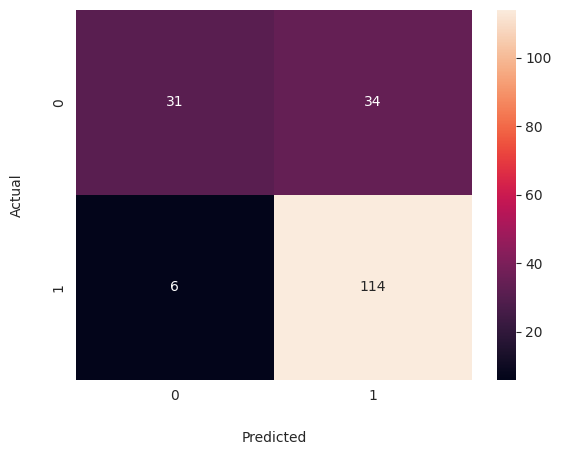

In [34]:
RFC = RandomForestClassifier()
model_clf = RFC
clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test)

In [35]:
from google.colab import files
files.download("random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Train : 
               precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185

r2 score of LogisticRegression = 0.05128205128205121 



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross Validation Score of LogisticRegression = 0.818139534883721 

Training Accuracy: 0.7837837837837838


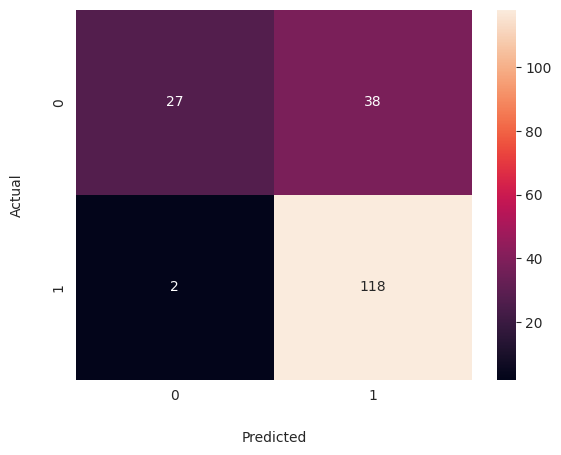

In [36]:
logr = LogisticRegression(max_iter=1000, random_state=42)
model_clf = logr
clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test)

# Decision Tree Classifier

DecisionTreeClassifier Train : 
               precision    recall  f1-score   support

           0       0.48      0.45      0.46        65
           1       0.71      0.74      0.73       120

    accuracy                           0.64       185
   macro avg       0.60      0.59      0.60       185
weighted avg       0.63      0.64      0.63       185

r2 score of DecisionTreeClassifier = -0.5891025641025642 

Cross Validation Score of DecisionTreeClassifier = 0.7178112175102599 

Training Accuracy: 0.6378378378378379


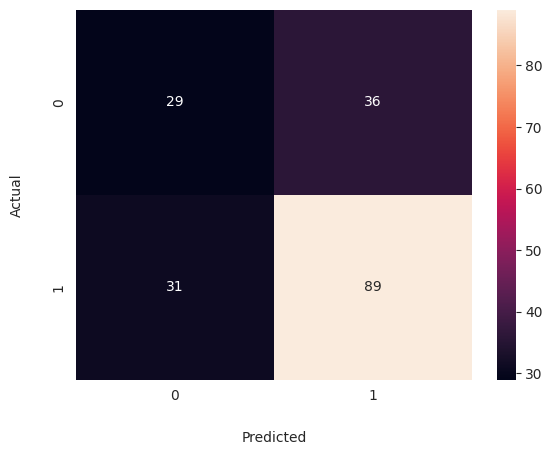

In [37]:
DTC = DecisionTreeClassifier()
model_clf = DTC
clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test)

# Gradient Boosting Classifier

GradientBoostingClassifier Train : 
               precision    recall  f1-score   support

           0       0.72      0.40      0.51        65
           1       0.74      0.92      0.82       120

    accuracy                           0.74       185
   macro avg       0.73      0.66      0.67       185
weighted avg       0.73      0.74      0.71       185

r2 score of GradientBoostingClassifier = -0.16217948717948727 

Cross Validation Score of GradientBoostingClassifier = 0.7994801641586867 

Training Accuracy: 0.7351351351351352


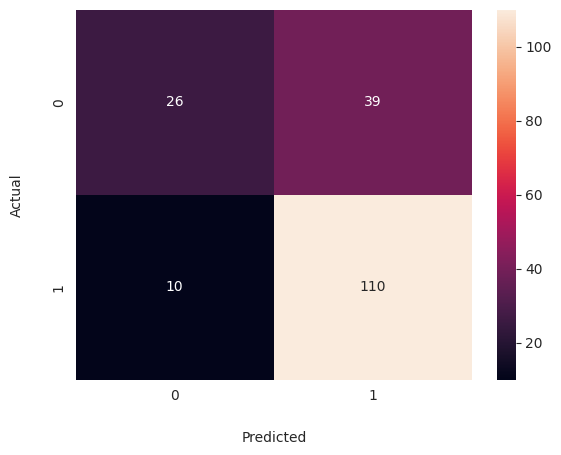

In [38]:
GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_clf = GBC
clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test)

# Fine Tuning

RandomForestClassifier Train : 
               precision    recall  f1-score   support

           0       0.92      0.37      0.53        65
           1       0.74      0.98      0.85       120

    accuracy                           0.77       185
   macro avg       0.83      0.68      0.69       185
weighted avg       0.81      0.77      0.73       185

r2 score of RandomForestClassifier = -0.0198717948717948 

Cross Validation Score of RandomForestClassifier = 0.7901778385772914 

Training Accuracy: 0.7675675675675676


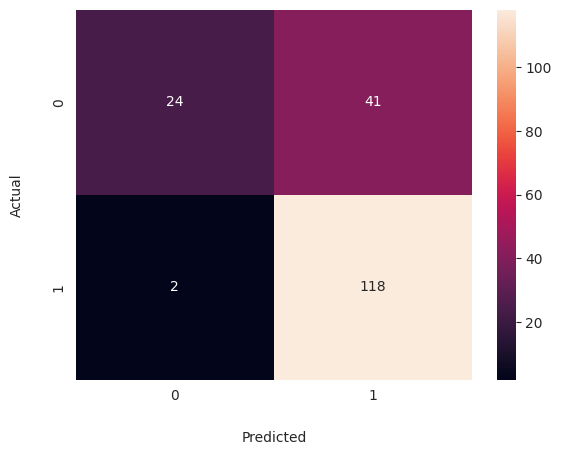

In [39]:
model_clf = RandomForestClassifier(n_estimators=100,min_samples_split=25, max_depth=7,max_features=1)
clf(model_clf,x_status, y_status,x_train, x_test, y_train, y_test)

Saving the model

In [40]:
import pickle

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on your training data
rf_model.fit(x_train, y_train)

# Save the model to a file
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)


In [41]:
with open('random_forest_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Now you can use it for predictions
y_pred = loaded_model.predict(x_test)

# **Testing The Model on the Test Dataset**

In [42]:
test_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


<Axes: >

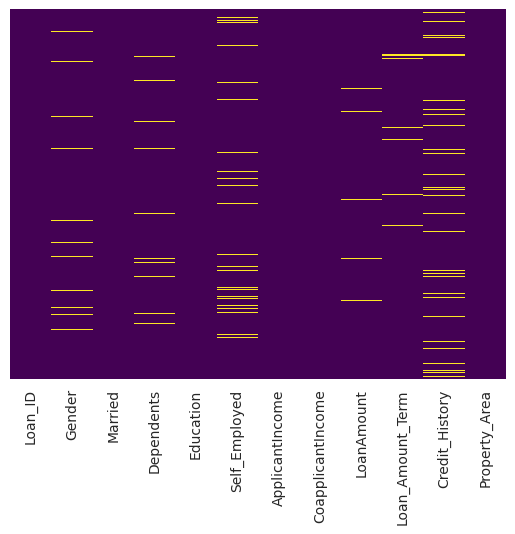

In [43]:
sns.heatmap(test_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [44]:
test_data ['Gender'] = test_data ['Gender'].fillna(test_data['Gender'].mode()[0])
test_data ['Married'] = test_data ['Married'].fillna(test_data['Married'].mode()[0])
test_data ['Dependents'] = test_data ['Dependents'].fillna(test_data['Dependents'].mode()[0])
test_data ['Self_Employed'] = test_data ['Self_Employed'].fillna(test_data['Self_Employed'].mode()[0])

In [45]:
test_data ['LoanAmount'] = test_data ['LoanAmount'].fillna(test_data['LoanAmount'].mean())
test_data ['Loan_Amount_Term'] = test_data ['Loan_Amount_Term'].fillna(test_data['Loan_Amount_Term'].mean())
test_data ['Credit_History'] = test_data ['Credit_History'].fillna(test_data['Credit_History'].mean())

<Axes: >

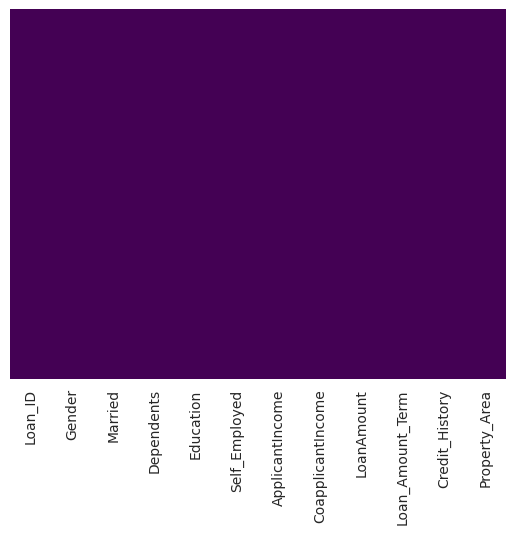

In [46]:
sns.heatmap(test_data.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [47]:
label_encoder = preprocessing.LabelEncoder()
cols = ['Gender','Married','Education','Self_Employed','Property_Area','Dependents']
for col in cols:
  test_data[col] = label_encoder.fit_transform(test_data[col])

In [48]:
test_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.000000,2
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.000000,2
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.000000,2
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,0.825444,2
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.000000,2


In [49]:
test_data.drop(['Loan_ID'],axis=1,inplace=True)

In [50]:
RFC = RandomForestClassifier()
RFC.fit(x_train, y_train)
pred_lr = RFC.predict(test_data)

# Accuracy Check

Accuracy: 0.772972972972973
              precision    recall  f1-score   support

           0       0.78      0.49      0.60        65
           1       0.77      0.93      0.84       120

    accuracy                           0.77       185
   macro avg       0.78      0.71      0.72       185
weighted avg       0.77      0.77      0.76       185



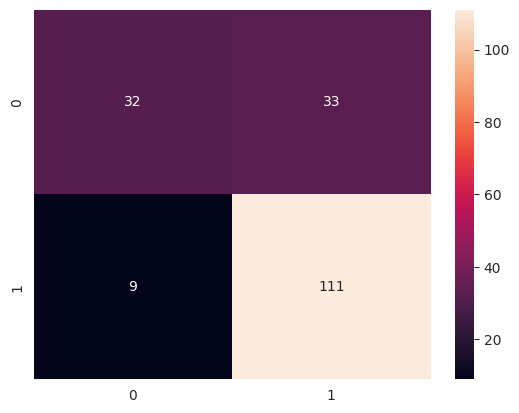

In [51]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g')
plt.show()

# Model Choice and Justification

We tested multiple classification models to predict loan approval, including:

*   Random Forest Classifier
*   Logistic Regression
*   Decision Tree Classifier
*   Gradient Boosting Classifier

After comparing training accuracy and cross-validation scores, we chose Random Forest as our final model because:

1. **Handles complex relationships:** Random Forest can capture nonlinear patterns and interactions between features, which simpler models like Logistic Regression cannot handle as effectively.

2. **Robustness:** It is less sensitive to outliers and noise in the data, making predictions more reliable.

3. **High cross-validation score:** Although the accuracy is 77%, the cross-validation score is 81%, showing good generalization to unseen data.

4. **Multiple models tested:** Logistic Regression gave a similar accuracy (~78%), but it may fail to capture complex feature interactions. Decision Tree and Gradient Boosting had lower or comparable performance.

**Note:** While 77% accuracy is lower than the ideal 90%, it is reasonable for this dataset due to its size, missing values, and class imbalance. The focus is on robust and interpretable predictions, rather than just maximizing accuracy.

# GUI

In [52]:
import gradio as gr
import numpy as np
import pandas as pd
import pickle

# Load model
with open('random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

mapping = {
    'Gender': {'Male':1, 'Female':0},
    'Married': {'Yes':1, 'No':0},
    'Education': {'Graduate':1, 'Not Graduate':0},
    'Self_Employed': {'Yes':1, 'No':0},
    'Property_Area': {'Urban':2, 'Semiurban':1, 'Rural':0},
    'Credit_History': {'Yes':1, 'No':0},
    'Dependents': {'0':0, '1':1, '2':2, '3+':3}
}

def predict_loan_logic(gender, married, dependents, education, self_emp,
                       income, co_income, loan_amt, term, credit, area):

    input_data = np.array([
        mapping['Gender'][gender],
        mapping['Married'][married],
        mapping['Dependents'][dependents],
        mapping['Education'][education],
        mapping['Self_Employed'][self_emp],
        int(income or 0),
        int(co_income or 0),
        int(loan_amt or 0),
        int(term or 360),
        mapping['Credit_History'][credit],
        mapping['Property_Area'][area]
    ]).reshape(1, -1)

    pred = model.predict(input_data)[0]
    proba = model.predict_proba(input_data)[0][pred]   # 0–1

    status = "APPROVED" if pred == 1 else "NOT APPROVED"
    color = "#16A34A" if pred == 1 else "#DC2626"      # green / red

    conf_low = max(0, proba - 0.08)
    conf_high = min(1, proba + 0.08)

    # CSV
    df = pd.DataFrame({'Status':[status], 'Confidence':[f"{proba*100:.1f}%"]})
    csv_string = df.to_csv(index=False)
    csv_string_encoded = csv_string.replace("\n","%0A").replace(",","%2C")

    # HTML output with GLOWING GAUGE
    html_output = f"""
    <div style="padding:20px; font-family: 'Poppins', 'Segoe UI', sans-serif; background-color:#F9FAFB; color:#022C22;">

        <!-- GLOWING SEMI-CIRCLE GAUGE -->
        <div style="text-align:center; margin-bottom:25px;">
            <div style="position: relative; width: 260px; height: 130px; margin: 0 auto;">
                <svg viewBox="0 0 260 130" width="260" height="130"
                     style="filter: drop-shadow(0 6px 14px rgba(16,185,129,0.45));">
                    <!-- Grey track -->
                    <path d="M20 120 A110 110 0 0 1 240 120"
                          fill="none" stroke="#E5E7EB" stroke-width="18" stroke-linecap="round"/>

                    <!-- Green progress arc (length ~345, scaled by proba) -->
                    <path d="M20 120 A110 110 0 0 1 240 120"
                          fill="none" stroke="url(#grad)" stroke-width="18" stroke-linecap="round"
                          stroke-dasharray="345"
                          stroke-dashoffset="{345 - 345 * proba}">
                    </path>

                    <!-- Gradient definition -->
                    <defs>
                        <linearGradient id="grad" x1="0%" y1="0%" x2="100%" y2="0%">
                            <stop offset="0%" stop-color="#22C55E"/>
                            <stop offset="50%" stop-color="#16A34A"/>
                            <stop offset="100%" stop-color="#4ADE80"/>
                        </linearGradient>
                    </defs>

                    <!-- Glowing tip dot -->
                    <circle cx="{20 + 220 * proba}" cy="120"
                            r="7" fill="#BBF7D0" stroke="#16A34A" stroke-width="3"
                            style="filter: drop-shadow(0 0 10px rgba(34,197,94,0.9));"/>
                </svg>

                <!-- Numeric readout -->
                <div style="position:absolute; left:0; right:0; bottom:8px; text-align:center;">
                    <div style="font-size:34px; font-weight:800; color:#022C22;
                                text-shadow:0 2px 4px rgba(15,23,42,0.15);">
                        {int(proba*100)}<span style="font-size:18px;">%</span>
                    </div>
                    <div style="font-size:18px; font-weight:700; color:{color};
                                letter-spacing:1px; margin-top:2px;">
                        {status}
                    </div>
                </div>
            </div>

            <div style="font-size:16px; font-weight:600; color:#047857; margin-top:12px;">
                📊 Confidence Interval: {int(conf_low*100)}% – {int(conf_high*100)}%
            </div>
        </div>

        <!-- Next Steps - GREEN CARD -->
        <div style="background: linear-gradient(135deg, #16A34A, #22C55E);
                    padding:24px; border-radius:18px; color:white;
                    box-shadow: 0 12px 30px rgba(22,163,74,0.4);">
            <h3 style="margin-top:0; font-size:22px; font-weight:800; letter-spacing:0.5px;">
                {'✅ Next Steps' if pred==1 else '🟢 Improve Eligibility'}
            </h3>
            <ul style="line-height:1.8; font-size:16px; padding-left:20px; margin:0;">
                <li>✔️ {'Proceed to SBP Application' if pred==1 else "Improve / Fix Credit History"}</li>
                <li>✔️ {'Prepare CNIC & Income Proof' if pred==1 else "Increase Income or Add Co-applicant"}</li>
                <li>✔️ <a href="https://www.sbp.org.pk/" target="_blank"
                          style="color:#DCFCE7; text-decoration:none; font-weight:700;">
                        SBP Portal</a></li>
            </ul>
        </div>

        <!-- Buttons -->
        <div style="text-align:center; margin-top:22px;">
            <a href="https://www.sbp.org.pk/" target="_blank"
               style="background: linear-gradient(135deg, #059669, #16A34A); color:white;
                      padding:12px 30px; text-decoration:none; border-radius:999px;
                      font-weight:700; display:inline-block; margin-bottom:14px;
                      box-shadow:0 8px 20px rgba(5,150,105,0.35);">
                💡 Need Help with Loan Process?
            </a>
            <br/>
            <a href="data:text/csv;charset=utf-8,{csv_string_encoded}" download="loan_result.csv"
               style="background: linear-gradient(135deg, #22C55E, #4ADE80); color:#022C22;
                      padding:12px 30px; text-decoration:none; border-radius:999px;
                      font-weight:700; display:inline-block; margin-top:8px;
                      box-shadow:0 8px 20px rgba(34,197,94,0.35);">
                📥 Download Report
            </a>
        </div>
    </div>
    """
    return html_output

# GUI
with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as demo:
    # Header - GREEN & WHITE
    gr.HTML("""
    <div style="text-align:center; padding:25px;
                background: linear-gradient(135deg, #022C22, #065F46);
                color:white; border-radius:20px;
                box-shadow:0 20px 50px rgba(6,95,70,0.5);
                font-family:'Poppins','Segoe UI',sans-serif;">
        <h1 style="margin:0; font-size:2.6em; font-weight:800;">🏦 Loan Approval Predictor</h1>
        <p style="margin:6px 0 0 0; font-size:1.15em; opacity:0.95;">
            Pakistan Smart ML Fintech Tool
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 👤 Applicant Info")
            gender = gr.Dropdown(['Male','Female'], label="Gender", value="Male")
            married = gr.Dropdown(['Yes','No'], label="Married", value="No")
            deps = gr.Dropdown(['0','1','2','3+'], label="Dependents", value="0")
            edu = gr.Dropdown(['Graduate','Not Graduate'], label="Education", value="Graduate")
            self_emp = gr.Dropdown(['Yes','No'], label="Self Employed", value="No")

            gr.Markdown("### 💰 Financial Details")
            inc = gr.Number(label="Applicant Income", value=5000)
            co_inc = gr.Number(label="Coapplicant Income", value=0)
            amt = gr.Number(label="Loan Amount (thousands)", value=120)
            trm = gr.Number(label="Loan Term (months)", value=360)

            gr.Markdown("### 🏘️ Credit & Property")
            cred = gr.Dropdown(['Yes','No'], label="Credit History", value="Yes")
            prop = gr.Dropdown(['Urban','Semiurban','Rural'], label="Property Area", value="Urban")

            submit_btn = gr.Button("🚀 Predict & Apply", variant="primary")

        with gr.Column(scale=1):
            output_html = gr.HTML(label="🔮 Live Results")

    submit_btn.click(
        predict_loan_logic,
        inputs=[gender, married, deps, edu, self_emp, inc, co_inc, amt, trm, cred, prop],
        outputs=output_html
    )

demo.launch(share=True)


/tmp/ipykernel_7306/1658763055.py:143: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0f06d0b896a210b59a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [55]:
%%writefile app.py

import gradio as gr
import numpy as np
import pandas as pd
import pickle

# Load model
with open('random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Categorical mappings
mapping = {
    'Gender': {'Male':1, 'Female':0},
    'Married': {'Yes':1, 'No':0},
    'Education': {'Graduate':1, 'Not Graduate':0},
    'Self_Employed': {'Yes':1, 'No':0},
    'Property_Area': {'Urban':2, 'Semiurban':1, 'Rural':0},
    'Credit_History': {'Yes':1, 'No':0},
    'Dependents': {'0':0, '1':1, '2':2, '3+':3}
}

def predict_loan_logic(gender, married, dependents, education, self_emp,
                       income, co_income, loan_amt, term, credit, area):

    # Prepare input
    input_data = np.array([
        mapping['Gender'][gender],
        mapping['Married'][married],
        mapping['Dependents'][dependents],
        mapping['Education'][education],
        mapping['Self_Employed'][self_emp],
        int(income or 0),
        int(co_income or 0),
        int(loan_amt or 0),
        int(term or 360),
        mapping['Credit_History'][credit],
        mapping['Property_Area'][area]
    ]).reshape(1, -1)

    # Get probabilities
    probs = model.predict_proba(input_data)[0]
    approval_prob = probs[1]  # Probability of APPROVED
    rejection_prob = probs[0]

    # Determine status strictly from approval probability
    status = "APPROVED" if approval_prob >= 0.5 else "NOT APPROVED"
    color = "#16A34A" if approval_prob >= 0.5 else "#DC2626"

    # Confidence interval (±8%)
    conf_low = max(0, approval_prob - 0.08)
    conf_high = min(1, approval_prob + 0.08)

    # CSV Export
    df = pd.DataFrame({
        'Status': [status],
        'Approval Probability': [f"{approval_prob*100:.1f}%"],
        'Rejection Probability': [f"{rejection_prob*100:.1f}%"]
    })
    csv_string = df.to_csv(index=False)
    csv_string_encoded = csv_string.replace("\n","%0A").replace(",","%2C")

    # Gauge math
    arc_length = 345
    dash_offset = arc_length - arc_length * approval_prob
    dot_position = 20 + 220 * approval_prob

    html_output = f"""
    <div style="padding:20px; font-family:'Poppins','Segoe UI',sans-serif; background:#F9FAFB;">

        <div style="text-align:center; margin-bottom:25px;">

            <div style="position:relative; width:260px; height:130px; margin:0 auto;">
                <svg viewBox="0 0 260 130" width="260" height="130">

                    <!-- Grey track -->
                    <path d="M20 120 A110 110 0 0 1 240 120"
                          fill="none"
                          stroke="#E5E7EB"
                          stroke-width="18"
                          stroke-linecap="round"/>

                    <!-- Dynamic colored arc -->
                    <path d="M20 120 A110 110 0 0 1 240 120"
                          fill="none"
                          stroke="{color}"
                          stroke-width="18"
                          stroke-linecap="round"
                          stroke-dasharray="{arc_length}"
                          stroke-dashoffset="{dash_offset}">
                    </path>

                    <!-- Moving indicator dot -->
                    <circle cx="{dot_position}" cy="120"
                            r="7"
                            fill="white"
                            stroke="{color}"
                            stroke-width="3"/>
                </svg>

                <!-- Numeric readout -->
                <div style="position:absolute; left:0; right:0; bottom:8px; text-align:center;">
                    <div style="font-size:34px; font-weight:800; color:#022C22;">
                        {int(approval_prob*100)}%
                    </div>
                    <div style="font-size:18px; font-weight:700; color:{color};">
                        {status}
                    </div>
                </div>
            </div>

            <div style="font-size:15px; font-weight:600; color:#374151; margin-top:12px;">
                Confidence Interval: {int(conf_low*100)}% – {int(conf_high*100)}%
            </div>
        </div>

        <!-- Next Steps Card -->
        <div style="background:{color}; padding:20px; border-radius:14px; color:white;">
            <h3 style="margin-top:0;">
                {'Next Steps' if approval_prob >= 0.5 else 'Improve Eligibility'}
            </h3>
            <ul style="line-height:1.7; margin:0; padding-left:18px;">
                <li>
                {'Proceed with documentation and SBP application.'
                 if approval_prob >= 0.5 else
                 'Improve credit history and financial stability.'}
                </li>
                <li>
                {'Prepare CNIC & income proof.'
                 if approval_prob >= 0.5 else
                 'Consider adding a co-applicant.'}
                </li>
            </ul>
        </div>

        <!-- Buttons -->
        <div style="text-align:center; margin-top:22px;">
            <a href="https://www.sbp.org.pk/" target="_blank"
               style="background:#065F46; color:white;
                      padding:12px 28px; text-decoration:none;
                      border-radius:999px; font-weight:700; display:inline-block;">
                Need Help with Loan Process?
            </a>

            <br/><br/>

            <a href="data:text/csv;charset=utf-8,{csv_string_encoded}"
               download="loan_result.csv"
               style="background:#D1FAE5; color:#065F46;
                      padding:12px 28px; text-decoration:none;
                      border-radius:999px; font-weight:700; display:inline-block;">
                Download Report
            </a>
        </div>
    </div>
    """

    return html_output


# GUI
with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as demo:

    gr.Markdown("## Loan Approval Predictor")

    with gr.Row():
        with gr.Column():
            gender = gr.Dropdown(['Male','Female'], label="Gender", value="Male")
            married = gr.Dropdown(['Yes','No'], label="Married", value="No")
            deps = gr.Dropdown(['0','1','2','3+'], label="Dependents", value="0")
            edu = gr.Dropdown(['Graduate','Not Graduate'], label="Education", value="Graduate")
            self_emp = gr.Dropdown(['Yes','No'], label="Self Employed", value="No")

            inc = gr.Number(label="Applicant Income", value=5000)
            co_inc = gr.Number(label="Coapplicant Income", value=0)
            amt = gr.Number(label="Loan Amount", value=120)
            trm = gr.Number(label="Loan Term", value=360)

            cred = gr.Dropdown(['Yes','No'], label="Credit History", value="Yes")
            prop = gr.Dropdown(['Urban','Semiurban','Rural'], label="Property Area", value="Urban")

            submit_btn = gr.Button("Predict", variant="primary")

        with gr.Column():
            output_html = gr.HTML()

    submit_btn.click(
        predict_loan_logic,
        inputs=[gender, married, deps, edu, self_emp, inc, co_inc, amt, trm, cred, prop],
        outputs=output_html
    )

demo.launch(share=True)

Overwriting app.py
